In [ ]:
!pip install -q gdown

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 70.6 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="x5DNcSDg0DhBtkANrOuZ")
project = rf.workspace("larcade-n").project("comvis-highway-c4fwr")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ComVis-Highway-3 in yolov8:: 100%|██████████| 1009/1009 [00:00<00:00, 9837.61it/s] 


In [ ]:
import os

dataset_root = "/content/ComVis-Highway-3"
data_yaml_path = "/content/ComVis-Highway-3/data.yaml"

print("data.yaml ada:", os.path.exists(data_yaml_path))
print("train ada:", os.path.exists("/content/ComVis-Highway-3/train"))
print("valid ada:", os.path.exists("/content/ComVis-Highway-3/valid"))
print("test ada:", os.path.exists("/content/ComVis-Highway-3/test"))

data.yaml ada: True
train ada: True
valid ada: True
test ada: True


In [ ]:
dataset_root = os.path.dirname(data_yaml_path)

yaml_content = f"""
path: {dataset_root}
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['ComVis-Highway']
"""

with open(data_yaml_path, "w") as f:
    f.write(yaml_content)

print("✅ data.yaml updated")
print(yaml_content)

✅ data.yaml updated

path: /content/ComVis-Highway-3
train: train/images
val: valid/images
test: test/images

nc: 1
names: ['ComVis-Highway']



In [ ]:
required_paths = [
    "train/images",
    "train/labels",
    "valid/images",
    "valid/labels",
    "test/images",
    "test/labels"
]

for p in required_paths:
    full_path = os.path.join(dataset_root, p)
    print(p, "✅ ada" if os.path.exists(full_path) else "❌ tidak ada")

train/images ✅ ada
train/labels ✅ ada
valid/images ✅ ada
valid/labels ✅ ada
test/images ✅ ada
test/labels ✅ ada


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=512,
    batch=4,
    device=0,
    name="trained_yolo_model"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.59 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ComVis-Highway-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

In [ ]:
model = YOLO("runs/detect/trained_yolo_model/weights/best.pt")

model.predict(
    source=os.path.join(dataset_root, "test/images"),
    conf=0.25,
    save=True,
    device=0
)


image 1/44 /content/test/images/time_126-00s_frame_003780_jpg.rf.2b84cc797be21d57c74471460fc1d623.jpg: 640x640 11 ComVis-Highways, 6.4ms
image 2/44 /content/test/images/time_147-00s_frame_004410_jpg.rf.cfe8a08b3fd988f95669bbe89570bc59.jpg: 640x640 9 ComVis-Highways, 5.9ms
image 3/44 /content/test/images/time_148-50s_frame_004455_jpg.rf.6a73bf2e2a34c7b7cbbcc25455439053.jpg: 640x640 10 ComVis-Highways, 5.8ms
image 4/44 /content/test/images/time_154-50s_frame_004635_jpg.rf.2b810d2d255fe28d5da09ca8ce848e62.jpg: 640x640 10 ComVis-Highways, 5.9ms
image 5/44 /content/test/images/time_165-00s_frame_004950_jpg.rf.9ea111a68572302cfa13dfb7ad7ea22c.jpg: 640x640 11 ComVis-Highways, 5.8ms
image 6/44 /content/test/images/time_174-00s_frame_005220_jpg.rf.c6805fc7ac77b1ebb4926e4e4b729061.jpg: 640x640 8 ComVis-Highways, 7.4ms
image 7/44 /content/test/images/time_183-00s_frame_005490_jpg.rf.5b944c44036e98f75e7ae4be30af7fd8.jpg: 640x640 12 ComVis-Highways, 5.8ms
image 8/44 /content/test/images/time_199-5

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'ComVis-Highway'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0,

Jumlah hasil prediksi: 13


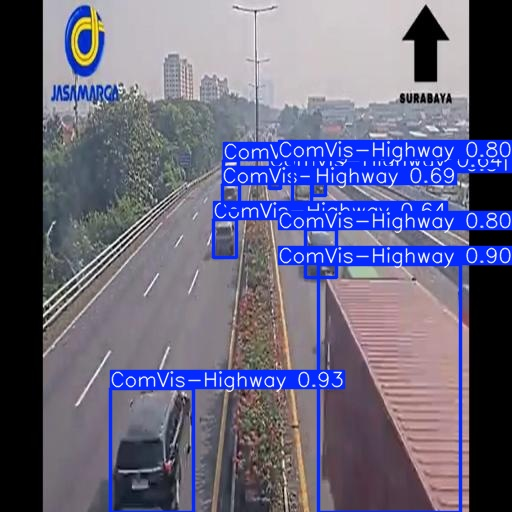

In [ ]:
import glob
from IPython.display import Image, display

pred_images = glob.glob("runs/detect/predict/*.jpg") + glob.glob("runs/detect/predict/*.png")

print("Jumlah hasil prediksi:", len(pred_images))

if pred_images:
    display(Image(filename=pred_images[0]))